# 6. A pretrained encoder, and what it does not change

The obvious objection to this project's headline is that a model given no audio wins because the
audio models are weak. Hand engineered descriptors and a network trained from scratch on 134
recordings are both easy to dismiss that way.

So this notebook adds the model that objection asks for: wav2vec2, 94 million parameters, pretrained
on 960 hours of speech, used frozen. Only a linear head is fitted, once per fold, on the same folds
of the same recordings every other model here was scored on.

Run `python -m src.features.extract --config configs/base.yaml --extractor encoder` and then
`python -m src.train.cnn --config configs/base.yaml --name probe`. The figures below are read from
disk, because regenerating them needs the audio archive and the embedding cache, and neither is
committed.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src.config import load_config
from src.evaluate import families, tables
from src.results import config_directory, model_directory

cfg = load_config("configs/base.yaml")
REPORT = config_directory(cfg)
pd.set_option("display.width", 180)

print(
    f"encoder      : {cfg.encoder.architecture}, layer {cfg.encoder.layer}, "
    f"{cfg.encoder.pooling} pooled to {cfg.encoder.embedding_dim} dimensions"
)
print(f"checkpoint   : {cfg.encoder.checkpoint}")
print(f"expects      : {cfg.encoder.sample_rate} Hz")
print(f"corpus is at : {cfg.audio.target_sample_rate} Hz")

encoder      : wav2vec2_base, layer 6, mean pooled to 768 dimensions
checkpoint   : wav2vec2_fairseq_base_ls960.pth
expects      : 16000 Hz
corpus is at : 10000 Hz


## 1. What was added, and what was not

The encoder never moves. It runs once over every window, its output is cached like the log mel
spectrograms are, and the only thing fitted per fold is a linear map from 768 dimensions to three
classes. That is deliberate rather than lazy: a linear probe asks what the representation already
separates, and adding capacity would start answering a different question about what can be learned
from 134 recordings. The two networks in notebook 02 already answer that one.

Fitting a linear map over cached vectors is seconds per fold, which is why this model carries the
full fifty splits where the larger network carries five.

In [2]:
probe = pd.read_csv(model_directory(cfg, "probe") / "fold_metrics_clip.csv")
print(f"{len(probe)} splits: {probe.repeat.nunique()} repeats of {probe.fold.nunique()} folds")

provenance = pd.read_json(model_directory(cfg, "probe") / "provenance.json", typ="series")
print(f"feature source: {provenance['feature_source']}")
print(f"fitted on     : {provenance['accelerator']['device']}")

50 splits: 10 repeats of 5 folds
feature source: encoder
fitted on     : NVIDIA GeForce MX570 A


## 2. The upsampling, measured rather than asserted

The encoder expects 16 kHz. Every clip here is band limited to 5 kHz, so it is upsampled and the
encoder sees an empty band from 5 to 8 kHz.

That is the one place this project upsamples, and everywhere else it refuses to, because a file
upsampled from its native rate gains an empty band that identifies the equipment and therefore the
species. The argument for why it is safe here is that this band is empty for every clip of every
species, so it separates nothing. Below is the measurement rather than the argument.

In [3]:
band = pd.read_csv(cfg.paths.metadata / f"audit_upsampled_band_{cfg.name}.csv")
band["parts_per_million_above_nyquist"] = (band.share_above_nyquist * 1e6).round(2)
band[["species", "clips_measured", "share_above_nyquist", "parts_per_million_above_nyquist"]]

,species,clips_measured,share_above_nyquist,parts_per_million_above_nyquist
0,HumpbackWhale,40,0.000005,4.97
1,KillerWhale,40,0.000001,1.46
2,SpermWhale,40,0.000011,11.33


Between one and eleven parts per million of the energy sits above 5 kHz. That is resampler ringing
rather than signal.

One honest caveat, because the numbers do differ by a factor of ten across species. That residue is
a shadow of what each species has just below the cutoff rather than an independent channel: a clip
with more energy near 5 kHz leaves more ringing above it. At one part in a hundred thousand it is not
carrying a species label, but it is not identically zero either, and saying so is cheaper than being
caught.

## 3. The probe among the other audio models

Same folds, same recordings, same scoring. The `splits` column is the one to read first, because a
five split comparison must never be read as a fifty split one.

In [4]:
species = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
comparison = tables.comparison(cfg, list(species.names))
scores = tables.headline(comparison).sort_values("mean", ascending=False)
scores["splits"] = [
    len(pd.read_csv(model_directory(cfg, m) / "fold_metrics_clip.csv")) for m in scores.model
]
scores["hears the audio"] = [m not in species.floors for m in scores.model]
scores.round(4)

,model,mean,std,splits,hears the audio
3,logbook,0.9974,0.0045,50,False
5,metadata,0.8678,0.1344,50,False
0,xgboost,0.7524,0.0698,50,True
4,probe,0.7391,0.0902,50,True
1,cnn,0.7135,0.1230,5,True
2,cnn_small,0.7096,0.1418,50,True


The four audio models land within 0.05 of each other. They share nothing but their input: spectral
descriptors computed by hand, a small network trained from scratch, the same network at twenty times
the capacity, and a transformer that learned its representation from human speech.

That agreement is the point. It is what separates "our audio model was weak" from "the audio in this
corpus carries less than the paperwork does".

In [5]:
floor = families.strongest_floor(cfg, species)
against = tables.family_margins(cfg, species, control=floor)
print(f"every model against {floor}, which hears nothing:")
against.round(4)

every model against logbook, which hears nothing:


,model,mean,control,margin,low,high,p_value,agreeing,folds
0,xgboost,0.7524,0.9974,-0.2450,-0.3181,-0.1720,0.0000,50,50
3,probe,0.7391,0.9974,-0.2583,-0.3525,-0.1642,0.0000,50,50
1,cnn,0.7135,0.9983,-0.2848,-0.5136,-0.0560,0.0259,5,5
2,cnn_small,0.7096,0.9974,-0.2878,-0.4358,-0.1398,0.0003,50,50


## 4. What the correction across every comparison says

Thirty comparisons are reported across the three configurations. Reading each at 0.05 on its own
expects more than one to clear the bar carrying nothing, so they are corrected together.

In [6]:
adjusted = pd.read_csv(cfg.paths.reports / "multiplicity.csv")
survivors = adjusted[adjusted.rejected]
print(f"{len(adjusted)} comparisons, {len(survivors)} survive at q < 0.05")
print(
    f"of those, {(survivors.margin > 0).sum()} are positive, "
    f"and every positive one is a model that hears no audio"
)

survivors[["config", "model", "floor", "margin", "p_value", "q_value", "folds"]].round(6)

30 comparisons, 11 survive at q < 0.05
of those, 1 are positive, and every positive one is a model that hears no audio


,config,model,floor,margin,p_value,q_value,folds
0,wide_10k,xgboost,logbook,-0.494613,0.000000,0.000000,50
1,wide_10k,probe,logbook,-0.482667,0.000000,0.000000,50
2,wide_10k,logbook,metadata,0.345202,0.000000,0.000000,50
3,base_10k,xgboost,logbook,-0.245030,0.000000,0.000000,50
4,base_10k,probe,logbook,-0.258350,0.000001,0.000008,50
5,base_5k,probe,logbook,-0.273657,0.000004,0.000020,50
6,base_5k,xgboost,logbook,-0.247419,0.000247,0.001058,50
7,base_10k,cnn_small,logbook,-0.287780,0.000285,0.001070,50
8,wide_10k,xgboost,metadata,-0.149411,0.001342,0.004472,50
9,base_5k,probe,metadata,-0.176418,0.001768,0.005304,50


## 5. Where the probe sits when the giveaway is taken away

Notebook 01 established that the collection code and the recording site name the species before any
audio is heard. This is the probe on the clips where a field cannot answer.

In [7]:
ambiguity = pd.read_csv(REPORT / "ambiguity_breakdown.csv")
ambiguity.pivot_table(index="model", columns="subset", values="macro_f1_mean").round(3)

subset,collection code not recorded,collection code unique to a species,native sample rate shared by species,native sample rate unique to a species
model,,,,
cnn,0.581,0.711,0.707,0.644
cnn_small,0.609,0.708,0.671,0.671
logbook,0.638,0.998,0.864,0.932
metadata,0.698,0.867,0.683,0.878
probe,0.514,0.746,0.708,0.679
xgboost,0.616,0.750,0.661,0.705


## 6. What it cost

Worth recording, because the reason this model carries fifty splits and the larger network carries
five is entirely a matter of cost.

In [8]:
cache = sorted(cfg.paths.processed.glob(f"{cfg.name}_encoder_*.npy"))
if cache:
    print(f"embedding cache: {cache[0].stat().st_size / 1e6:.0f} MB for {len(probe)} splits")
else:
    print("embedding cache is not on this machine; data/processed is gitignored")

history = pd.read_csv(model_directory(cfg, "probe") / "history.csv")
peaks = history[history.repeat == 0].groupby("fold").val_macro_f1.idxmax()
print(f"epochs to the best validation score: {history.loc[peaks].epoch.tolist()}")

embedding cache: 22 MB for 50 splits
epochs to the best validation score: [19, 44, 24, 50, 22]


confusion_probe.png


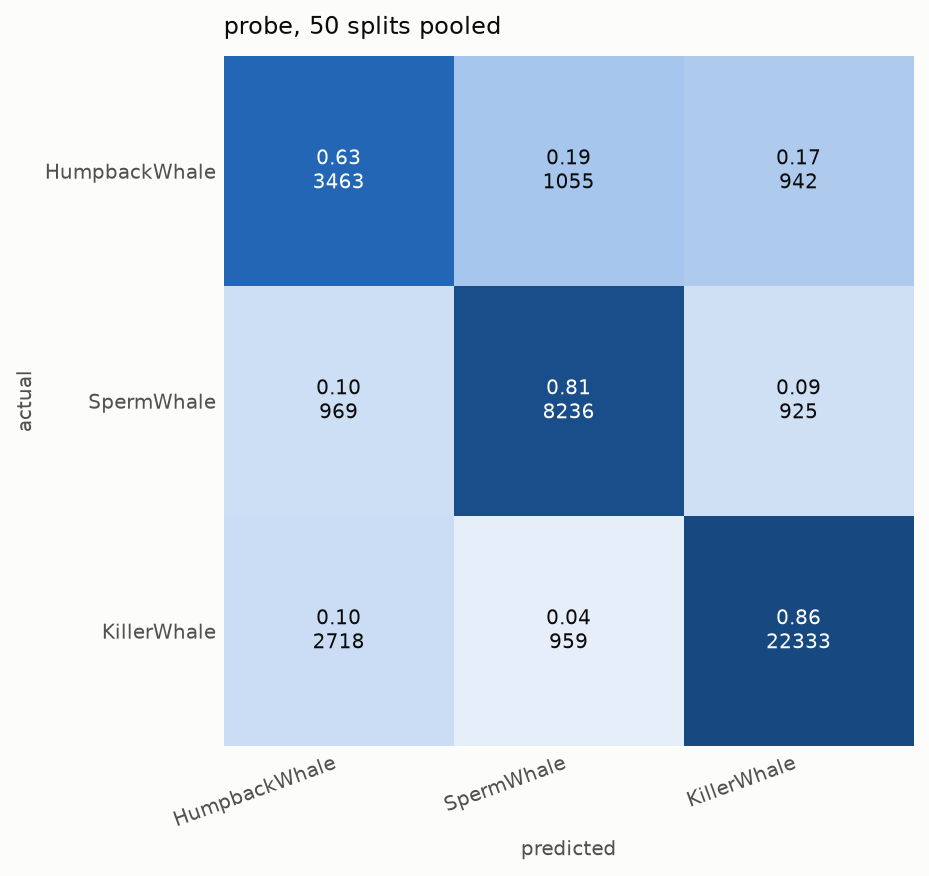

training_history_probe.png


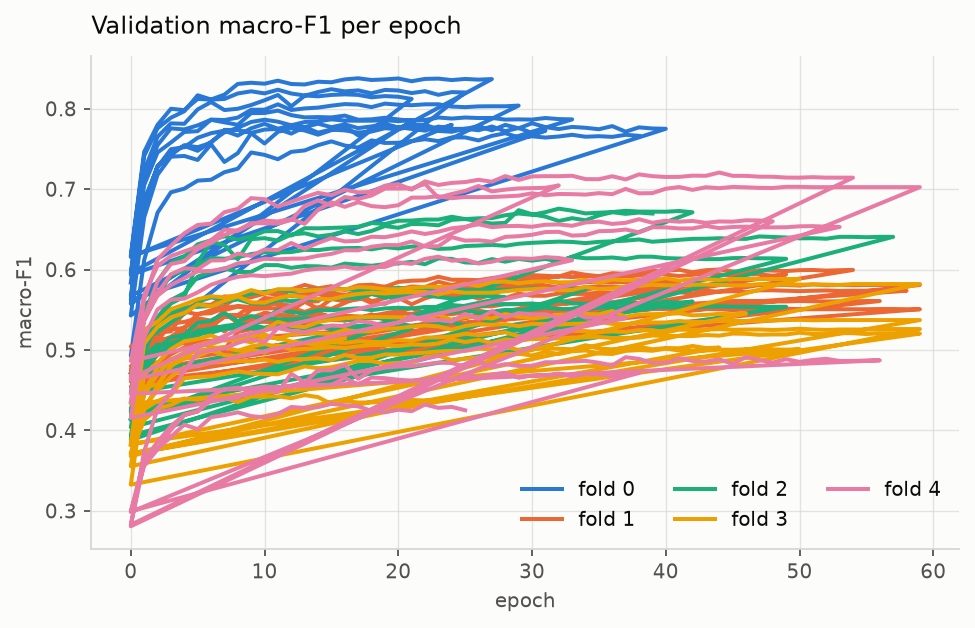

model_comparison.png


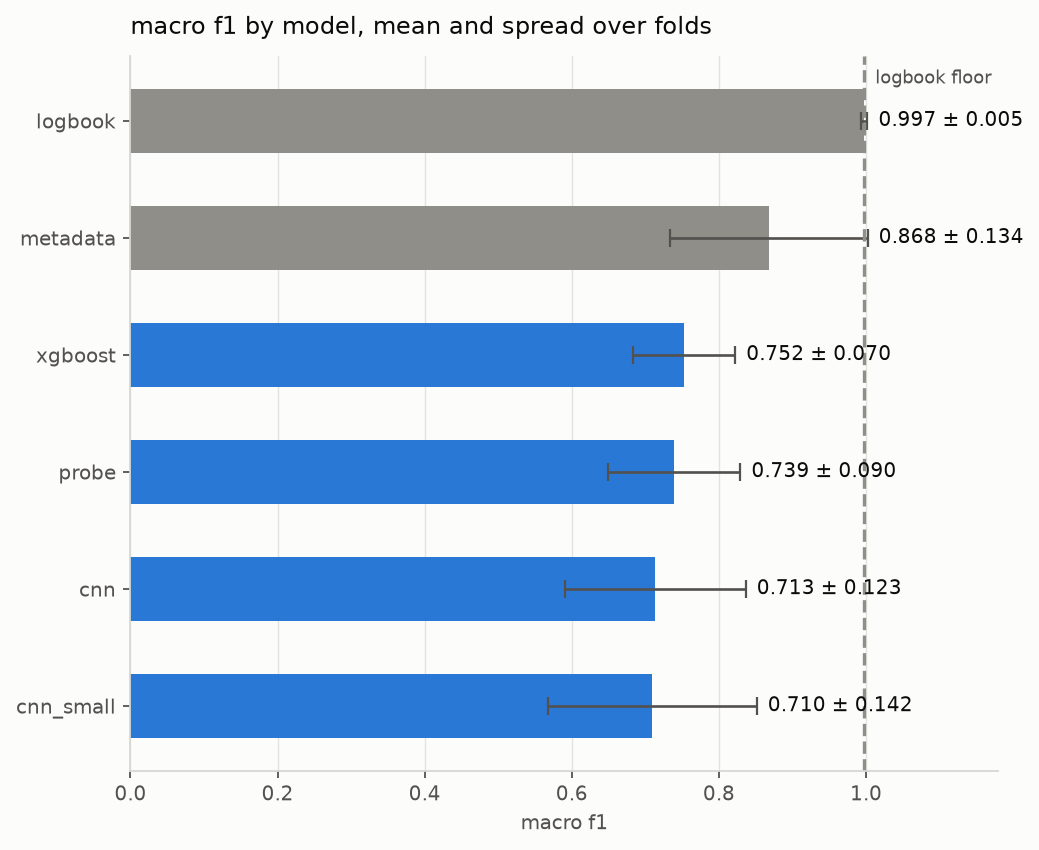

In [9]:
for name in ("confusion_probe.png", "training_history_probe.png", "model_comparison.png"):
    path = REPORT / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))

## What this notebook does not settle

wav2vec2 was pretrained on human speech. A model pretrained on animal vocalisation, such as Perch or
BirdNET, might transfer better, and nothing here speaks to that. This result rules out one objection
rather than every objection.

The layer is a prior rather than a tuned value. Speech pretrained transformers put phonetic structure
in their upper layers and more general acoustic structure lower down, so the sixth of twelve was
taken on that reasoning. Selecting it on a test fold would be the exact mistake this repository
exists to document, and selecting it properly would mean a validation only sweep that has not been
run.

The encoder sees audio band limited to 5 kHz. Killer whale whistles and sperm whale clicks both carry
energy well above that, so this is not the representation those calls deserve. It is the
representation the common band allows, which is the same constraint every other model here works
under.